<a href="https://colab.research.google.com/github/VanshYadav1403/Algo_Lab/blob/main/Lab_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Travelling Salesman Problem using Dynamic Programming.
Problem Description:
Given a set of cities and distances, find the shortest possible route that visits each city once and returns to the starting city.

#Theory
TSP uses dynamic programming with bit masking. Store results of visited subsets to reduce repeated work.

## Algorithm
1. Start from source city
2. Mark visited cities using bit mask
3. Try all unvisited cities
4. Choose minimum cost path
5. Return to source city

In [ ]:
def tsp(graph):
    n = len(graph)
    dp = [[-1]*(1<<n) for _ in range(n)]

    def visit(city, mask):
        if mask == (1<<n) - 1:
            return graph[city][0]

        if dp[city][mask] != -1:
            return dp[city][mask]

        ans = float('inf')

        for next_city in range(n):
            if mask & (1<<next_city) == 0:
                new_cost = graph[city][next_city] + visit(next_city, mask | (1<<next_city))
                if new_cost < ans:
                    ans = new_cost

        dp[city][mask] = ans
        return ans

    return visit(0, 1)


In [ ]:
graph = [
[0, 10, 15, 20],
[10, 0, 35, 25],
[15, 35, 0, 30],
[20, 25, 30, 0]
]

print("Minimum travelling cost:", tsp(graph))

Minimum travelling cost: 80


# Exercise
1. Print path of cities visited
2. Take graph input from user
3. Test with different number of cities

Enter number of cities: 4
Enter adjacency matrix:
0 10 15 20
10 0 35 25
15 35 0 30
20 25 30 0
Minimum cost: 80
Path (city indices): [0, 1, 3, 2, 0]
Path visited: City 0 -> City 1 -> City 3 -> City 2 -> City 0


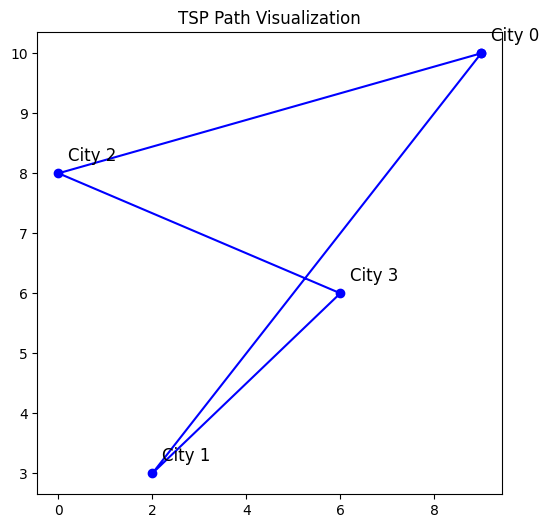

In [ ]:
import sys
import random
import matplotlib.pyplot as plt

n = int(input("Enter number of cities: "))

print("Enter adjacency matrix:")
graph = []
for _ in range(n):
    graph.append(list(map(int, input().split())))

dp = [[-1] * n for _ in range(1 << n)]
parent = [[-1] * n for _ in range(1 << n)]

def tsp(mask, pos):
    if mask == (1 << n) - 1:
        return graph[pos][0]

    if dp[mask][pos] != -1:
        return dp[mask][pos]
    ans = sys.maxsize
    for city in range(n):
        if mask & (1 << city) == 0:
            newAns = graph[pos][city] + tsp(mask | (1 << city), city)
            if newAns < ans:
                ans = newAns
                parent[mask][pos] = city

    dp[mask][pos] = ans
    return ans
min_cost = tsp(1, 0)
print("Minimum cost:", min_cost)

mask, pos = 1, 0
path = [0]
while True:
    next_city = parent[mask][pos]
    if next_city == -1:
        break
    path.append(next_city)
    mask |= (1 << next_city)
    pos = next_city
path.append(0)

print("Path (city indices):", path)
print("Path visited:", " -> ".join(f"City {c}" for c in path))

city_coords = [(random.randint(0, 10), random.randint(0, 10)) for _ in range(n)]

def plot_path(path, coords):
    plt.figure(figsize=(6,6))
    x = [coords[city][0] for city in path]
    y = [coords[city][1] for city in path]

    plt.plot(x, y, marker='o', linestyle='-', color='blue')

    for i, (cx, cy) in enumerate(coords):
        plt.text(cx+0.2, cy+0.2, f"City {i}", fontsize=12)

    plt.title("TSP Path Visualization")
    plt.show()

plot_path(path, city_coords)
